# Removing the batch norm layer from the discriminator
Originally (in the `mnist_gan` notebook) the ImageDiscriminator used BatchNorm layers, but this is actually not really recommended, so I took them out to see the difference, and we see slightly better results. (The ImageDiscriminator now has a flag about whether or not to use BatchNorm layers with a default of not using them)
Other than that, the model/training is exactly the same.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from synthetic_generation.gan.models import ImageGenerator, ImageDiscriminator
from synthetic_generation.gan.process import GANProcess

In [2]:
# load MNIST, normalize to [-1, 1] to match tanh output
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

In [ ]:
class ConditionalDataset(Dataset):
    """
    class used to create a Dataset where we replace the labels for
    the conditional with a one hot encoded version
    """
    def __init__(self, mnist_dataset, num_classes=10):
        self.dataset = mnist_dataset
        self.num_classes = num_classes
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        one_hot = torch.zeros(self.num_classes)
        one_hot[label] = 1.0
        return image, one_hot

In [ ]:
conditional_dataset = ConditionalDataset(train_dataset)
dataloader = DataLoader(conditional_dataset, batch_size=128, shuffle=True)

In [5]:
G = ImageGenerator(noise_dim = 100, output_dim = (1,28,28), conv_in_channels=256, num_conv_layers=2, conditional_dim = 10)
D = ImageDiscriminator(feature_dim = (1, 28, 28), conv_out_channels=64, num_conv_layers=2, conditional_dim=10)
process = GANProcess(G=G, D=D)
history = process.train(
    X=dataloader,
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

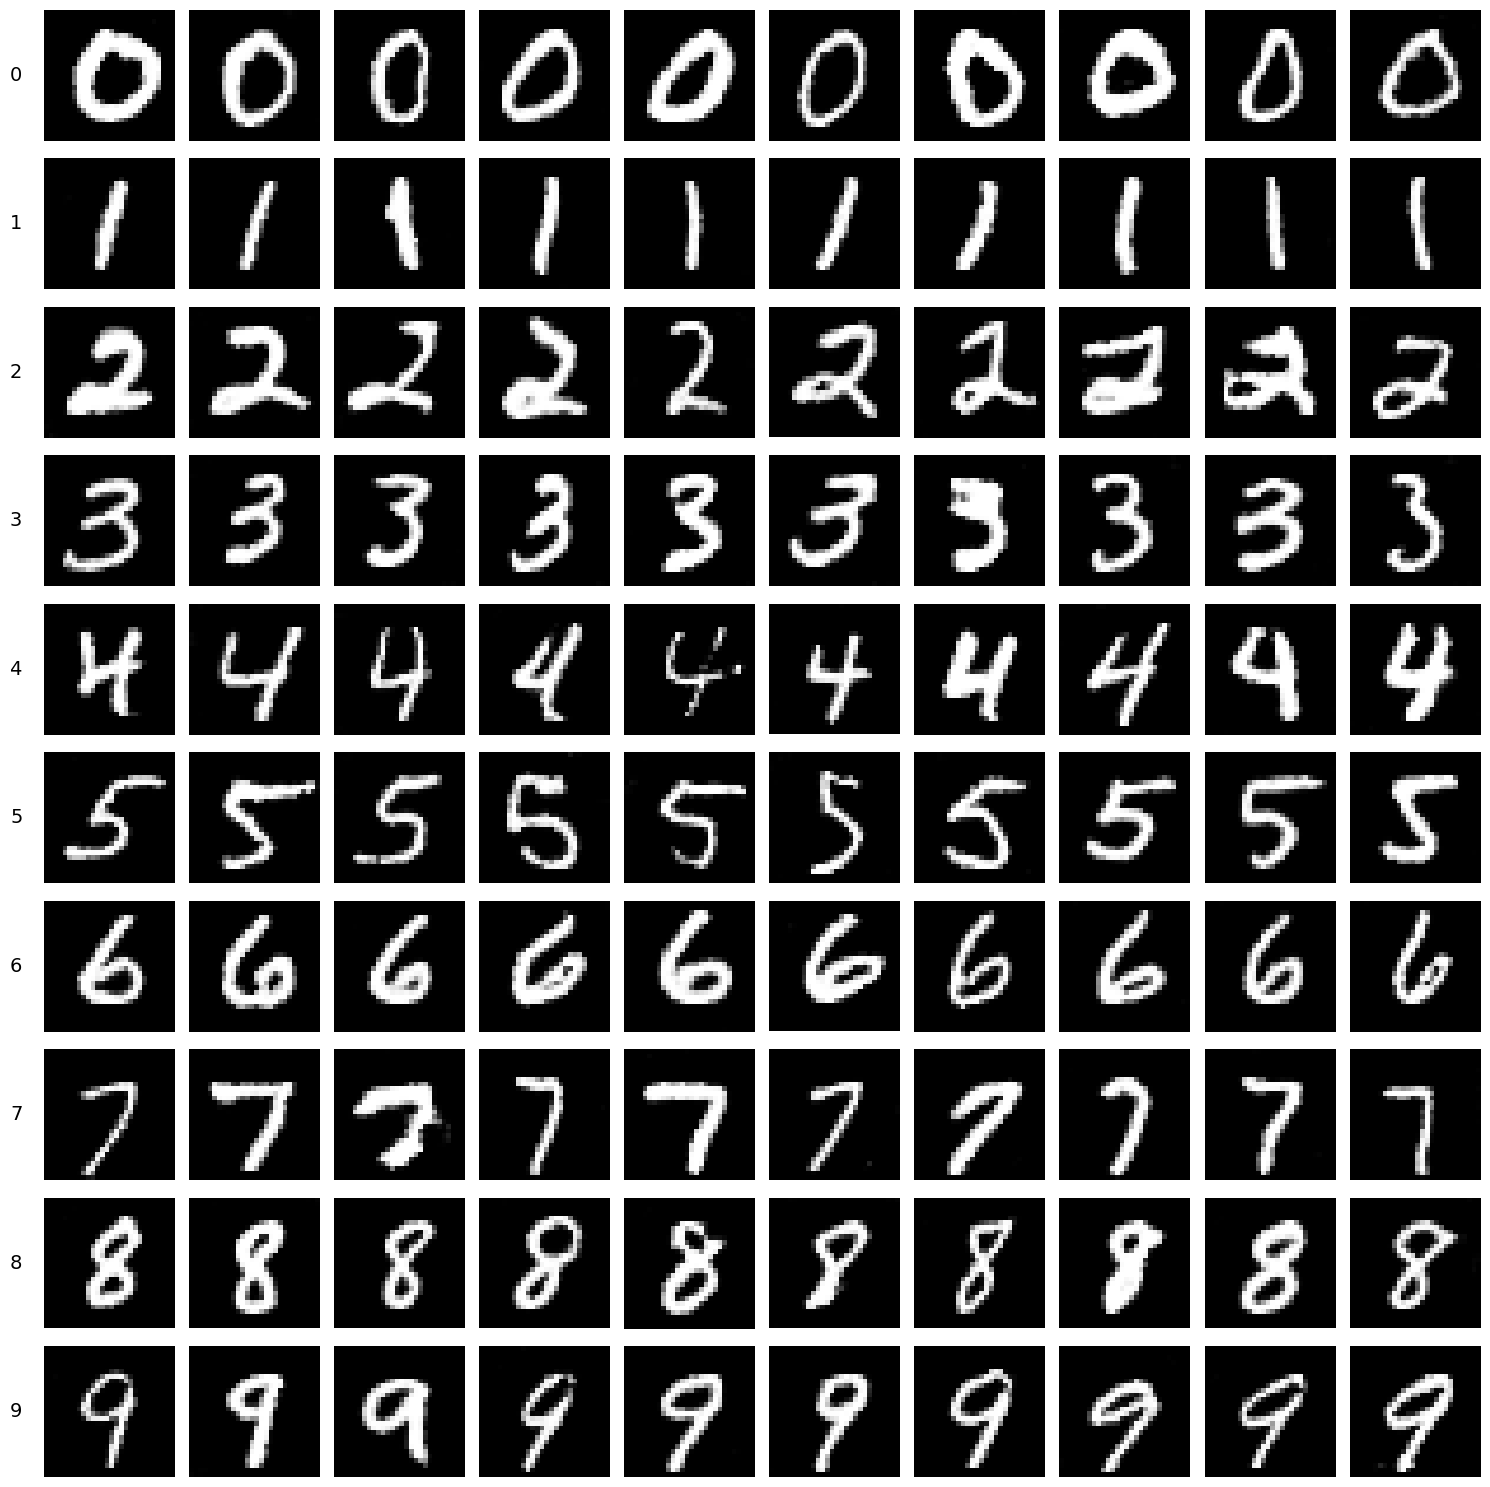

In [9]:
# generate 10 samples per digit class
n_samples = 10
all_samples = []
for digit in range(10):
    c = torch.zeros(n_samples, 10)
    c[:, digit] = 1.0
    samples = process.generate_samples(n_samples, c=c)
    all_samples.append(samples)

# plot 10x10 grid: rows = classes, columns = samples
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for digit, (row_axes, samples) in enumerate(zip(axes, all_samples)):
    for ax, sample in zip(row_axes, samples):
        ax.imshow(sample.squeeze(), cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    row_axes[0].set_ylabel(str(digit), fontsize=14, rotation=0, labelpad=20, va='center')
plt.tight_layout()
plt.show()

## Conclusions
The results we see are slightly better than we saw with the BatchNorm layers included. From this point we also look at 10 samples from each label, to make sure we are:
1. Consistently getting output that matches the class
2. Getting diversity within the class

We can see here that 1 is happening here, and 2 happens as well , more obviously in some classes (the class for 2 for example has some with loops, others without)

This architecture can be seen to handle this data quite well.